# Comparing four text lenses

**Input:** two author IOI text prompts. **Model:** GPT-2 small. **Tools:** Logit Lens, Tuned Lens, Jacobian Lens, and Attention Lens. Readouts describe hidden information; they do not causally establish that the decoded token controls the answer.

**Run mode:** the default cells replay real completed model measurements from `snapshots/`, using the public library visualization API. Saved outputs are retained. Set `RERUN = True` only after installing the model dependencies and configuring the optional run below. These examples are demonstrations, not dataset-level reproductions.

In [1]:
from pathlib import Path
import sys, json, os
ROOT = next(parent for parent in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
            if (parent / "demos" / "common.py").is_file() and (parent / "pyproject.toml").is_file())
sys.path[:0] = [str(ROOT), str(ROOT / "src")]
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, HTML, display
from vlm_probing import Prober
from vlm_probing.visualization import (plot_input, plot_lens_heatmap, plot_attention_comparison,
                                       plot_causal_heatmap, plot_intervention_curves)
from demos.common import ASSETS, load_snapshot, load_image, show_figure, gqa_input, target_ranks
RERUN = False  # Keep False for the bundled, genuinely measured offline results.
print("Offline replay of archived model measurements; no inference or training.")

Offline replay of archived model measurements; no inference or training.


In [2]:
record = load_snapshot("lens_comparison/text-readouts.json")
print("Model:", record["model_id"], "| revision:", record["model_revision"])
print("Fitting: Attention Lens 4,096 BookCorpus contexts; Jacobian Lens 256 WikiText-2 train contexts.")
print("Tuned Lens: imported author checkpoint. Validation/test: separate WikiText-2 splits.")

Model: openai-community/gpt2 | revision: e7da7f221d5bf496a48136c0cd264e630fe9fcc8
Fitting: Attention Lens 4,096 BookCorpus contexts; Jacobian Lens 256 WikiText-2 train contexts.
Tuned Lens: imported author checkpoint. Validation/test: separate WikiText-2 splits.


**Prompt:** When Amy and Laura got a snack at the house, Laura decided to give it to

**Candidate answer:** Amy

**Native continuation:**  her.

"I'm going

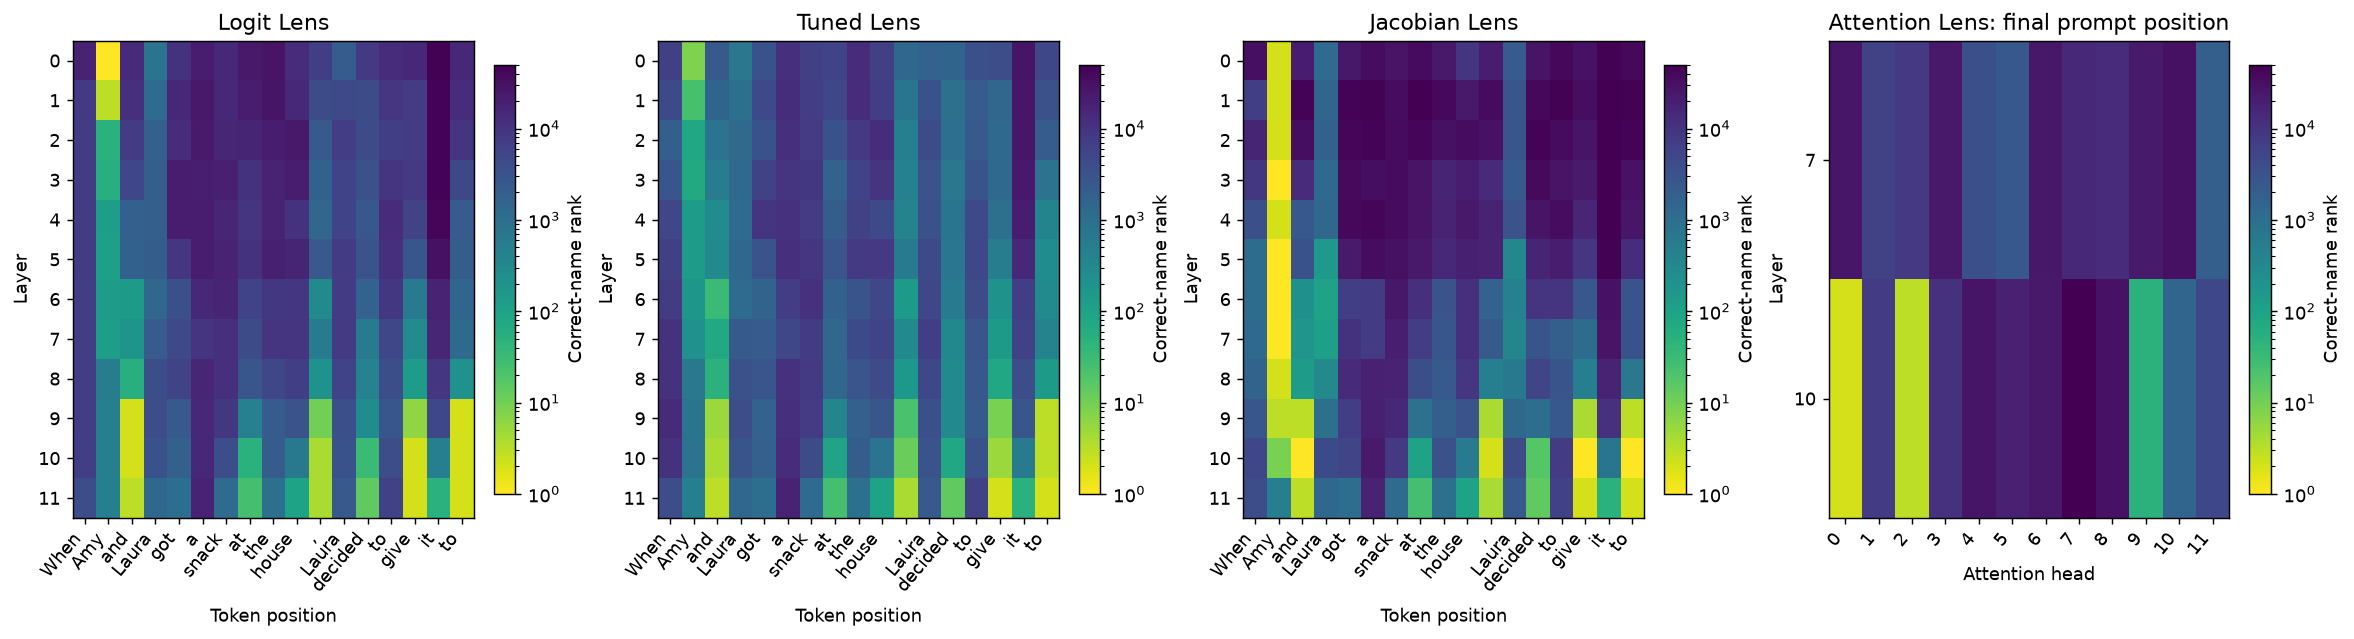

**Prompt:** Then, Danielle and Andrew had a lot of fun at the office. Andrew gave a computer to

**Candidate answer:** Danielle

**Native continuation:**  Danielle, and Danielle was able to use

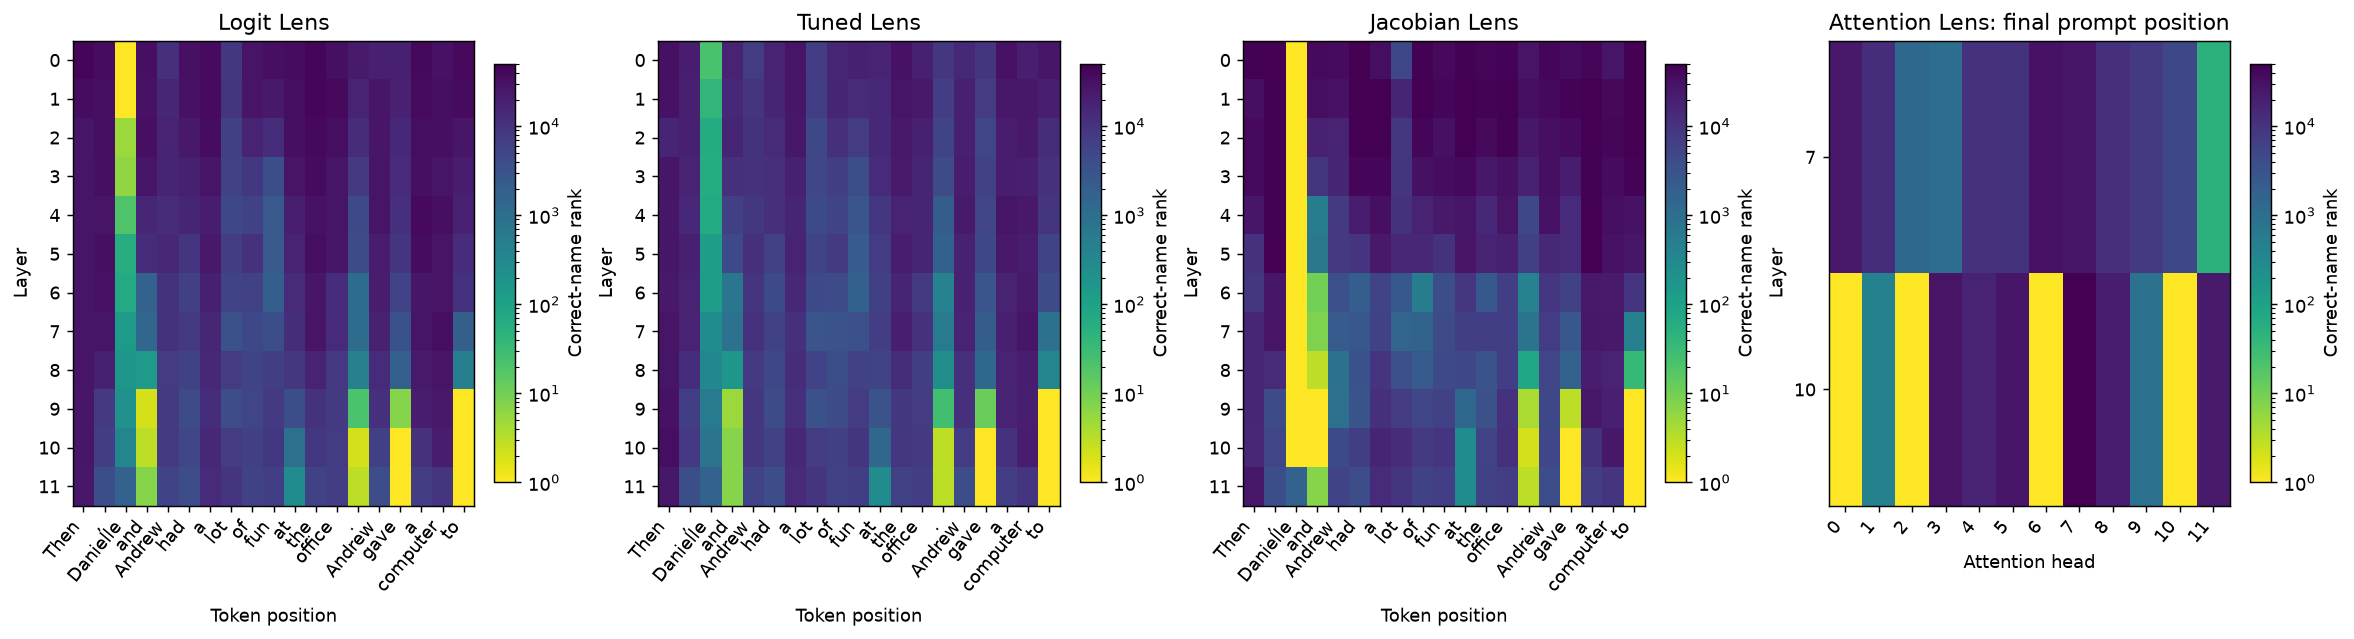

In [3]:
for example in record["examples"]:
    display(Markdown(f"**Prompt:** {example['clean_prompt']}\n\n**Candidate answer:** {example['positive_token'].strip()}\n\n**Native continuation:** {example['clean_baseline']['completion']}"))
    fig, axes = plt.subplots(1, 4, figsize=(18, 4.8), constrained_layout=True)
    for ax, method in zip(axes[:3], ["logit", "tuned", "jacobian"]):
        view = example["views"][method]
        plot_lens_heatmap(np.asarray(view["targets"]["correct_name"]["rank"]),
                         layer_labels=view["layers"], token_labels=example["input_tokens"],
                         ax=ax, title=method.title() + " Lens", value_label="Correct-name rank",
                         vmin=1, vmax=50257)
    view = example["views"]["attention"]
    ranks = np.asarray(view["targets"]["correct_name"]["rank"])[:, :, -1]
    plot_lens_heatmap(ranks, layer_labels=view["layers"], token_labels=list(range(ranks.shape[1])),
                     ax=axes[3], title="Attention Lens: final prompt position", value_label="Correct-name rank",
                     vmin=1, vmax=50257)
    axes[3].set_xlabel("Attention head")
    show_figure(fig)

**How to read:** the first three panels share the same prompt positions and vocabulary rank scale; rank 1 is best. Attention Lens instead decodes individual head outputs at the final prompt position. Its rows are the two genuinely fitted head layers (7 and 10), so this panel is a different coordinate view. Jacobian readouts were recalibrated at all 12 residual layers. The last layer agrees with the native readout; earlier readouts differ in when names become decodable.

## Optional new model run

This cell is deliberately opt-in. `VLM_PROBING_MODEL` selects a Hugging Face model ID or local checkpoint; `VLM_PROBING_DEVICE` selects the device. Hugging Face uses its normal cache (`HF_HOME` can relocate it). Rerunning performs fresh forwards and may need a GPU. An architecture-specific input adapter may be needed when changing the model; inspect `probe.describe()` first.

In [4]:
if RERUN:
    from demos.runtime import bind_model, fitted_method
    probe, tokenizer, device = bind_model("openai-community/gpt2")
    example = record["examples"][1]
    inputs = dict(tokenizer(example["clean_prompt"], return_tensors="pt").to(device))
    target_id = tokenizer.encode(example["positive_token"], add_special_tokens=False)
    if len(target_id) != 1:
        raise ValueError("Select a single-token candidate for this rank demo")
    methods = {"Logit": probe.lens.logit(tokens="text")}
    # Enable after supplying model-bound fitted artifacts in VLM_PROBING_LENS_CONFIG.
    if os.environ.get("VLM_PROBING_LENS_CONFIG"):
        methods.update({name.title(): fitted_method(probe, name, tokens="text")
                        for name in ("tuned", "jacobian", "attention")})
    for name, method in methods.items():
        result = method.run(inputs)
        ax = plot_lens_heatmap(result, tensor="head_logits" if name == "Attention" else None,
                               target_token_id=target_id[0], head=0 if name == "Attention" else None,
                               title=name + " Lens: fresh model run")
        show_figure(ax.figure)
else:
    print("Fresh inference skipped; set RERUN=True to execute the public method calls above.")

Fresh inference skipped; set RERUN=True to execute the public method calls above.


## Sources and interpretation

**IOI data:** [author CSV](https://github.com/hannamw/eap-ig-faithfulness/tree/main/data/ioi), published rows 826 and 475. **Methods:** [Logit Lens](https://www.lesswrong.com/posts/AcKRB8wDpdaN6v6ru/interpreting-gpt-the-logit-lens), [Tuned Lens](https://arxiv.org/abs/2303.08112), [Attention Lens](https://arxiv.org/abs/2310.16270), [Jacobian Lens](https://transformer-circuits.pub/2026/workspace/index.html). **Calibration sources:** [WikiText-2](https://huggingface.co/datasets/Salesforce/wikitext), [BookCorpus release](https://storage.googleapis.com/huggingface-nlp/datasets/bookcorpus/bookcorpus.tar.bz2). Lens artifact bindings must match the exact model/tokenizer/readout/calibration; see [fitted-lens configuration](lens-config.example.json).

Bundled image and data attribution is listed in [README.md](README.md) and [image notices](assets/images/SOURCE_NOTICES.md). Model checkpoints and fitted lens artifacts are not included.